# Задача 4: Эволюция бетатронных частот при выключенном ВЧ

**Условие:**
В накопителе с постоянным ведущим полем циркулирует протонный пучок с энергией $E$. ВЧ выключено, нелинейные поля отсутствуют, собственным полем пучка можно пренебречь. Как меняются бетатронные частоты частиц в пучке от времени?

**Физический анализ:**

1.  **Отсутствие ВЧ (RF off):** Это означает, что потери энергии пучка не компенсируются ускоряющим полем.
2.  **Потери энергии:** Даже для протонов (тяжелых частиц) существует синхротронное излучение, хотя оно и мало по сравнению с электронами. Также возможны потери на ионизацию остаточного газа, но в вакууме накопителя основным диссипативным механизмом, зависящим от энергии, обычно считают синхротронное излучение (особенно при высоких энергиях).
    *   Мощность синхротронного излучения: $P_\gamma \propto E^4$.
    *   Следовательно, энергия частицы $E(t)$ и её импульс $p(t)$ монотонно убывают со временем.
3.  **Фокусировка:** Бетатронные частоты (тюны) $\nu_{x,y}$ определяются жесткостью магнитной структуры.
    *   Сила квадрупольной линзы $k$ (focusing strength) зависит от импульса частицы:
        $$ k = \frac{e G}{p c} $$
        где $G$ — градиент магнитного поля (константа), $p$ — импульс.
    *   При уменьшении импульса $p$, сила фокусировки $k$ **увеличивается**. Линзы становятся "сильнее" для потерявших энергию частиц.
4.  **Хроматизм:** Зависимость частоты бетатронных колебаний от импульса характеризуется хроматизмом $\xi$:
    $$ \frac{\Delta \nu}{\nu} = \xi \frac{\Delta p}{p} $$
    *   Для "натуральной" хроматизма (определяемого только квадруполями) $\xi < 0$. Это следует из того, что более энергичные частицы фокусируются слабее ($k \sim 1/p$), а значит имеют меньшую частоту колебаний.
    *   Следовательно, при уменьшении импульса ($\Delta p < 0$) и отрицательном хроматизме ($\xi < 0$), изменение частоты положительно ($\Delta \nu > 0$).

**Вывод:**
Так как энергия (и импульс) протонов уменьшается со временем из-за радиационных потерь, а фокусирующая система остается постоянной, "жесткость" фокусировки для этих частиц растет. Следовательно, **бетатронные частоты частиц увеличиваются со временем**.

Кроме того, из-за уменьшения импульса в постоянном ведущем поле $B$, радиус орбиты $R = p/(eB)$ будет уменьшаться — пучок будет спиралировать внутрь кольца.

---
Ниже приведено численное моделирование этого процесса для параметров, близких к LHC (где синхротронное излучение протонов уже заметно).

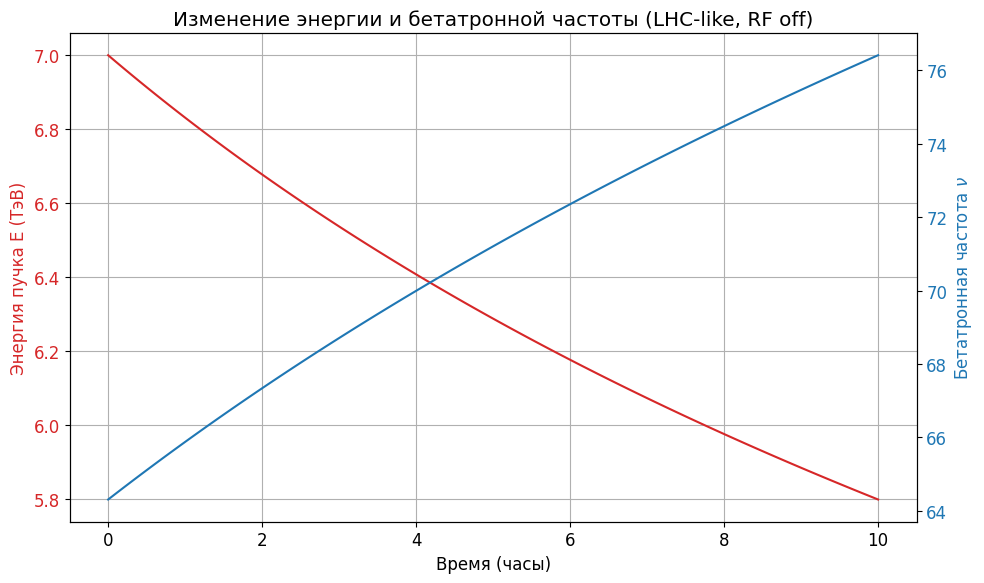

Начальная энергия: 7.0000 ТэВ
Конечная энергия: 5.7986 ТэВ
Изменение частоты: 12.097538


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Константы
c = 299792458.0       # Скорость света, м/с
m_p = 938.272e6       # Масса протона, эВ/c^2
e_charge = 1.602e-19  # Элементарный заряд, Кл

# Параметры накопителя (пример LHC)
E0_TeV = 7.0          # Начальная энергия, ТэВ
E0 = E0_TeV * 1e12    # эВ
R = 4243.0            # Средний радиус, м (LHC circumference ~ 27 km)
B_dipole = 8.33       # Тл (примерно)

# Бетатронная частота (Tune)
nu_0 = 64.31          # Рабочая точка LHC

# Хроматизм (Natural Chromaticity)
# Обычно xi ~ -nu (для FODO структуры)
xi = -nu_0 

# Расчет потерь на синхротронное излучение
# U0 (eV per turn) = C_gamma * E^4 / rho
# Для протонов: P ~ gamma^4.
# Формула: U0 [keV] = 6.03 * E[TeV]^4 / rho[km] (для электронов)
# Для протонов нужно масштабировать на (m_e/m_p)^4
m_e = 0.511e6
ratio_mass = (m_e / m_p)**4

def energy_loss_per_turn(E_eV, R_m):
    # E в эВ, R в м
    # Классическая формула: P = (2/3) * r_c * c * gamma^4 / rho^2 * m c^2 ?
    # Проще через релятивистский фактор
    gamma = E_eV / m_p
    # Мощность излучения P = (e^2 c / 6 pi epsilon_0) * (gamma^4 / R^2)
    # Потери за оборот U0 = P * (2 pi R / c) = (e^2 / 3 epsilon_0) * gamma^4 / R
    # В единицах эВ: U0_eV = (e / 3 epsilon_0) * gamma^4 / R
    
    epsilon_0 = 8.854e-12
    U0_J = (e_charge**2 / (3 * epsilon_0)) * (gamma**4) / R_m
    U0_eV = U0_J / e_charge
    return U0_eV

# Моделирование
t_max_hours = 10.0 # Моделируем 10 часов (процесс очень медленный для протонов)
dt_hours = 0.1
steps = int(t_max_hours / dt_hours)
time_hours = np.linspace(0, t_max_hours, steps)

E_vals = np.zeros(steps)
nu_vals = np.zeros(steps)

E_current = E0
nu_current = nu_0

# Частота обращения
f_rev = c / (2 * np.pi * R) # Гц

for i, t in enumerate(time_hours):
    E_vals[i] = E_current
    nu_vals[i] = nu_current
    
    # Вычисляем потери
    U0 = energy_loss_per_turn(E_current, R)
    
    # Потери энергии за шаг времени dt
    # dE/dt = -U0 * f_rev
    dE_dt = -U0 * f_rev # эВ/с
    
    dt_sec = dt_hours * 3600
    dE = dE_dt * dt_sec
    
    # Обновляем энергию
    E_new = E_current + dE
    
    # Обновляем тюн через хроматизм
    # d_nu = xi * (dp/p)
    # Для релятивистских частиц dp/p approx dE/E
    d_nu = xi * (dE / E_current) # dE отрицательное, xi отрицательное -> d_nu положительное
    
    nu_new = nu_current + d_nu
    
    E_current = E_new
    nu_current = nu_new

# Визуализация
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Время (часы)')
ax1.set_ylabel('Энергия пучка E (ТэВ)', color=color)
ax1.plot(time_hours, E_vals / 1e12, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Бетатронная частота $\\nu$', color=color)
ax2.plot(time_hours, nu_vals, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Изменение энергии и бетатронной частоты (LHC-like, RF off)')
fig.tight_layout()
plt.show()

print(f"Начальная энергия: {E_vals[0]/1e12:.4f} ТэВ")
print(f"Конечная энергия: {E_vals[-1]/1e12:.4f} ТэВ")
print(f"Изменение частоты: {nu_vals[-1] - nu_vals[0]:.6f}")